In [1]:
import matplotlib.pyplot as plt
import rebound
import numpy as np
from scipy import signal
import matplotlib.image as mpimg

In [3]:
#fourrier transform helper functions

m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1


def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx


In [ ]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=1.05*8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e

f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ with $2e$ From Original Chaotic Plot')
plt.savefig('1_01xalpha.png')
plt.show()

In [9]:
#graphing and simulation functions

def sim_and_graph(change_ecc, change_a_s):
    sim = rebound.Simulation()
    sim.integrator = "whfast"
    sim.dt = 1e-1
    sim.add(m=1, hash = "Sun")
    sim.add(m=m_jup,a=5.6,e=change_ecc*0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
    sim.add(m=m_sat,a=change_a_s*8.9,e=change_ecc*0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

    sim.move_to_com()

    times = np.linspace(0,1e7,int(1e5))*2*np.pi
    long_peri_sat = np.zeros(len(times))
    e_sat = np.zeros(len(times))
    long_peri_j = np.zeros(len(times))
    e_j = np.zeros(len(times))

    for i in range(len(times)):
        sim.integrate(times[i])
        long_peri_sat[i] = sim.particles[2].pomega
        e_sat[i] = sim.particles[2].e
        long_peri_j[i] = sim.particles[1].pomega
        e_j[i] = sim.particles[1].e

    f,pxx = pomega_ft(times, long_peri_sat, e_sat)

    plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
    plt.xscale('log')
    plt.ylabel('Power (With Power Spectral Density Scaling)')
    plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
    plt.xlim(1e-7,1e-2)

In [11]:
ecc_vals = [0.1,0.5,1,1.5,2]
a_sat_vals = [1.01,1.005,1,0.995,0.99]

count = 0
for i in ecc_vals:
    for j in a_sat_vals:
        sim_and_graph(i,j)
        plt.savefig(f'{count}.png')
        count += 1
        plt.clf()


<Figure size 640x480 with 0 Axes>

In [2]:
imgs = []
for i in range(25):
    imgs.append(mpimg.imread(f'{i}.png'))

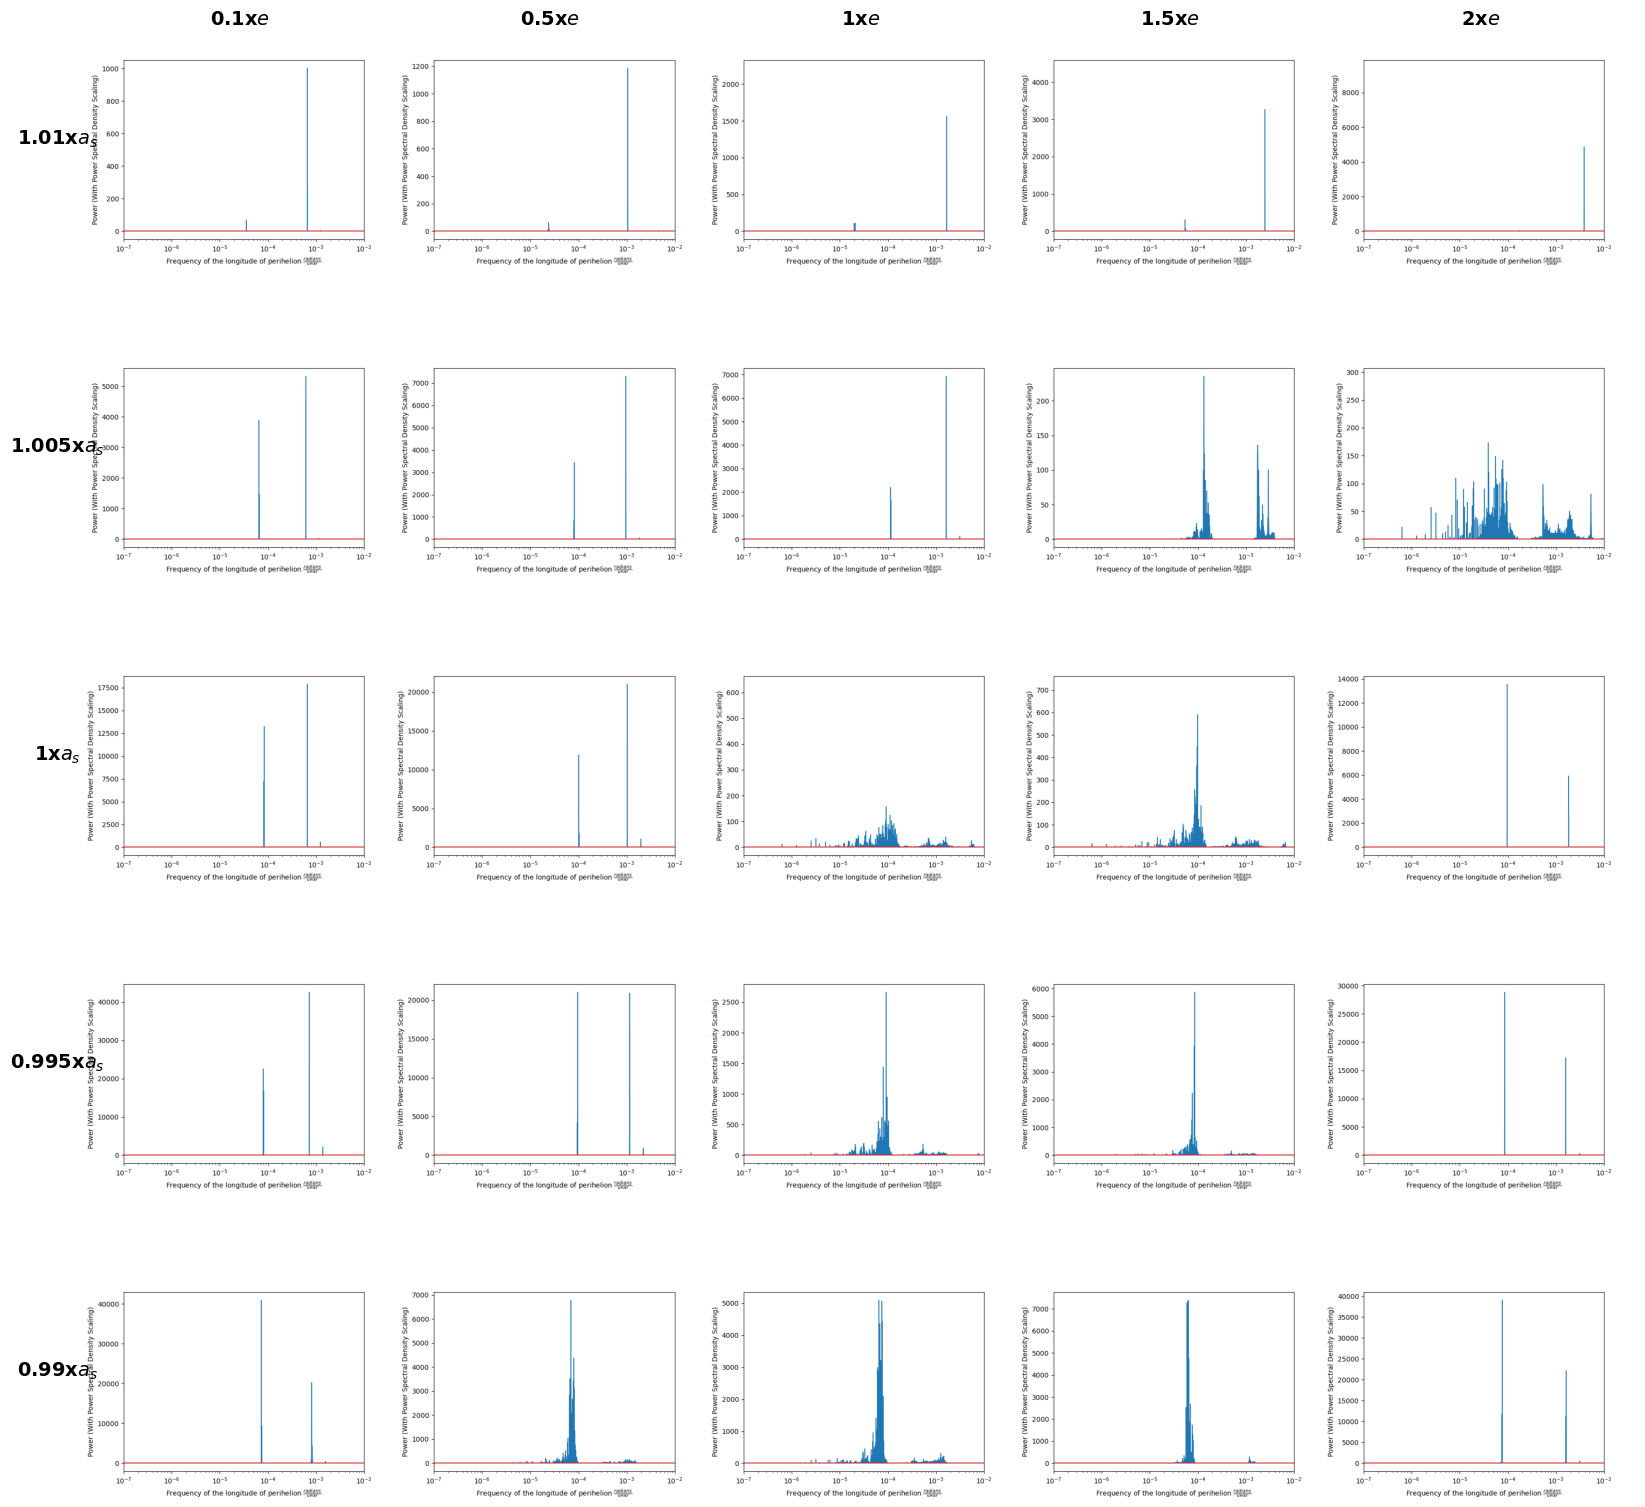

In [14]:
row_labels = ['1.01', '1.005', '1', '0.995', '0.99']
col_labels = ['0.1', '0.5', '1', '1.5', '2']

fig, axes = plt.subplots(5, 5, figsize=(20, 20))

for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    ax.set_xticks([])
    ax.set_yticks([])   
    for spine in ax.spines.values():
        spine.set_visible(False)
    row = i // 5
    col = i % 5
    if row == 0:
        ax.set_title(rf'{col_labels[col]}x$e$', fontweight='bold', size=14)
    if col == 0:
        ax.set_ylabel(rf'{row_labels[row]}x$a_s$', fontweight='bold', size=14, rotation=0, labelpad=20)

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()